In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('boston_House_Data.csv')

In [3]:
df.sample(20)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
4016,Built-up Area,Ready To Move,Green Glen Layout,2 BHK,Blisera,1075,2.0,1.0,60.00
6278,Super built-up Area,18-Jul,Bhoganhalli,4 BHK,Rosha I,2119,4.0,2.0,111.00
3649,Super built-up Area,19-Nov,Sarjapur Road,2 BHK,AsastDe,984,2.0,1.0,45.91
10949,Built-up Area,Ready To Move,Green Glen Layout,3 BHK,Sravea,1740,3.0,3.0,80.00
12526,Super built-up Area,Ready To Move,Yelenahalli,2 BHK,NaN,1160,2.0,2.0,44.08
11606,Plot Area,Ready To Move,BTM 4th Stage,2 Bedroom,NaN,1350,2.0,0.0,90.00
5521,Super built-up Area,19-Mar,Hosa Road,3 BHK,Sosisic,1525.84,3.0,1.0,117.00
1249,Plot Area,Ready To Move,TC Palaya,2 Bedroom,Lancy R,1240,2.0,1.0,60.00
10081,Super built-up Area,Ready To Move,Electronic City,2 BHK,MVnexde,890,2.0,1.0,40.00
11962,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,3 BHK,NaN,1021,3.0,2.0,59.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [5]:
df.shape

(13320, 9)

In [6]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [7]:
#Checking categorical vs numerical columns
df.dtypes

area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object

In [8]:
#Checking missing values
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [9]:
df.isnull().mean()*100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

In [10]:
#Univariete Analysis
for cols in df.columns:
    print(df[cols].value_counts())
    

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
16-Oct               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
location
Whitefield                         540
Sarjapur  Road                     399
Electronic City                    302
Kanakpura Road                     273
Thanisandra                        234
                                  ... 
3rd Stage Raja Rajeshwari Nagar      1
Chuchangatta Colony                  1
Electronic City Phase 1,             1
Chikbasavanapura                     1
Abshot Layout                        1
Name: count, Length: 1305, dtype: int64
size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BH

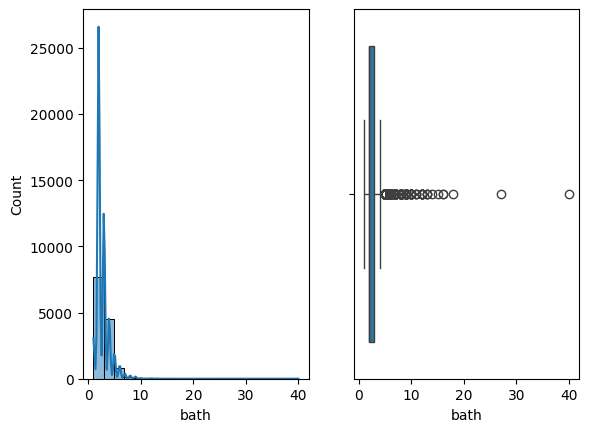

In [11]:
#Histogram for the numerical columns

plt.subplot(1,2,1)
sns.histplot(df['bath'],bins=20,kde=True)
plt.subplot(1,2,2)
sns.boxplot(x=df['bath'])
plt.show()

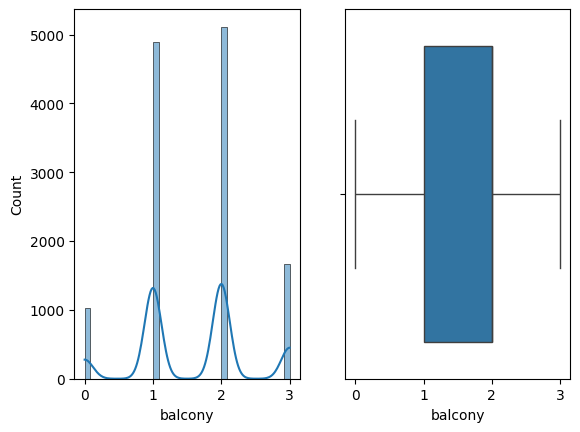

In [12]:
#Histogram for the numerical columns

plt.subplot(1,2,1)
sns.histplot(df['balcony'],kde=True)
plt.subplot(1,2,2)
sns.boxplot(x=df['balcony'])
plt.show()

<Axes: xlabel='area_type', ylabel='count'>

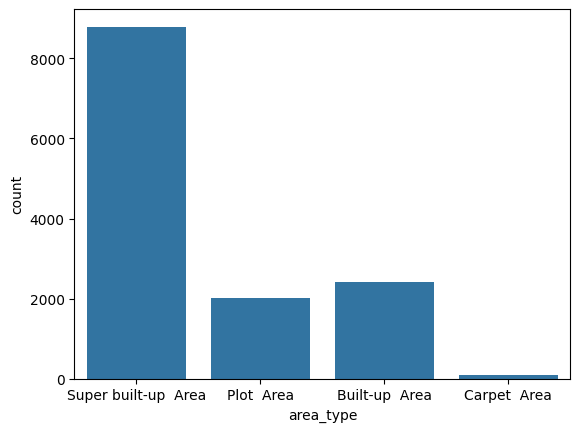

In [13]:
# univariete analysis for categorical columns

sns.countplot(x=df['area_type'])



In [14]:
# Multivariete Analysis

corr=df.corr(numeric_only=True)
corr

,bath,balcony,price
bath,1.000000,0.204201,0.456345
balcony,0.204201,1.000000,0.120355
price,0.456345,0.120355,1.000000


# Feature Engineering

Handling size column

In [15]:

df.sample(10)

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
10475,Plot Area,Ready To Move,RK Colony,9 Bedroom,NaN,1200,9.0,3.0,230.00
8591,Super built-up Area,19-Dec,Hoodi,2 BHK,Caycend,1063,2.0,1.0,61.17
4720,Built-up Area,Ready To Move,Thanisandra,3 BHK,Soitya,1690,3.0,2.0,125.00
1429,Super built-up Area,Ready To Move,Yelahanka,3 BHK,PuziaVe,1614,3.0,2.0,95.00
5181,Plot Area,Ready To Move,Gunjur,5 Bedroom,Chranya,6613,7.0,NaN,950.00
7904,Super built-up Area,18-Jul,CV Raman Nagar,2 BHK,NaN,1225,2.0,2.0,47.88
9842,Super built-up Area,Ready To Move,Dasanapura,2 BHK,Tavenew,545,2.0,1.0,22.34
12952,Super built-up Area,Ready To Move,Virupakshapura,2 BHK,Seamaha,1162,2.0,1.0,48.00
2254,Built-up Area,Ready To Move,Bommasandra,2 BHK,Vaodspe,877,2.0,2.0,30.00
6866,Super built-up Area,Ready To Move,Sarjapur Road,3 BHK,MJinele,1163,2.0,2.0,62.00


In [16]:
df['size'].value_counts()

size
2 BHK         5199
3 BHK         4310
4 Bedroom      826
4 BHK          591
3 Bedroom      547
1 BHK          538
2 Bedroom      329
5 Bedroom      297
6 Bedroom      191
1 Bedroom      105
8 Bedroom       84
7 Bedroom       83
5 BHK           59
9 Bedroom       46
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            8
8 BHK            5
11 BHK           2
10 BHK           2
11 Bedroom       2
27 BHK           1
19 BHK           1
43 Bedroom       1
16 BHK           1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [17]:
df['size']=df['size'].fillna(df['size'].mode()[0])


In [18]:
df['size'].isnull().sum()

np.int64(0)

In [19]:
#Splitting the mixed variables of size seperately
df['size_clean']=df['size'].str.extract(r'(\d+)').astype(int)
df['size_type']=df['size'].str.extract(r'([A-Za-z]+)')

df['size_type']=df['size_type'].str.lower()

df['size_type']=df['size_type'].replace({
	'bhk':'bedroom'
})

In [20]:
df['size_type'].value_counts()

size_type
bedroom    13307
rk            13
Name: count, dtype: int64

In [21]:
df=df.drop('size',axis=1)

In [22]:
df

,area_type,availability,location,society,total_sqft,bath,balcony,price,size_clean,size_type
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056,2.0,1.0,39.07,2,bedroom
1,Plot Area,Ready To Move,Chikka Tirupathi,Theanmp,2600,5.0,3.0,120.00,4,bedroom
2,Built-up Area,Ready To Move,Uttarahalli,NaN,1440,2.0,3.0,62.00,3,bedroom
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521,3.0,1.0,95.00,3,bedroom
4,Super built-up Area,Ready To Move,Kothanur,NaN,1200,2.0,1.0,51.00,2,bedroom
...,...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,ArsiaEx,3453,4.0,0.0,231.00,5,bedroom
13316,Super built-up Area,Ready To Move,Richards Town,NaN,3600,5.0,NaN,400.00,4,bedroom
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,Mahla T,1141,2.0,1.0,60.00,2,bedroom
13318,Super built-up Area,18-Jun,Padmanabhanagar,SollyCl,4689,4.0,1.0,488.00,4,bedroom


In [23]:
pd.set_option('display.max_rows', None)
df['total_sqft'].value_counts()

total_sqft
1200                 843
1100                 221
1500                 205
2400                 196
600                  180
1000                 172
1350                 133
1050                 123
1300                 117
1250                 114
900                  112
1400                 108
1800                 104
1150                 101
1600                 101
1140                  91
2000                  83
1450                  70
1650                  69
800                   67
1075                  66
3000                  66
1020                  63
2500                  62
1550                  60
1160                  60
1125                  60
950                   59
1180                  58
1700                  58
1260                  57
1255                  56
1080                  55
1220                  55
1070                  53
750                   52
700                   52
4000                  48
1225                  48
1175          

In [24]:
def clean_text(x):
    x=str(x).lower().strip()
    x=x.replace(',','')
    return x

In [25]:
def handle_range(x):
    if '-' in x:
        parts=x.strip('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except:
            return np.nan
    return x    

In [26]:
import re  # importing regex
def convert_sqft(x):
    #handling comma seperated values
    x=clean_text(x)
    
    #handling range
    x=handle_range(x)
    
    if isinstance(x, (int, float)):
        return float(x)
    
    num=re.findall(r'\d+\.?\d*',str(x))
    
    if not num:
        return np.nan
    num=float(num[0])
    
    
    if 'yards' in x or 'sq. yards' in x:
        return num*9
    
    if 'cents' in x:
        return num*435.6
    
    return num

In [27]:
df['total_sqft']=df['total_sqft'].apply(convert_sqft)

In [28]:
df.isnull().mean()*100

area_type        0.000000
availability     0.000000
location         0.007508
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
size_clean       0.000000
size_type        0.000000
dtype: float64

In [29]:
df['location']=df['location'].fillna(df['location'].mode()[0])

In [30]:
df['bath']=df['bath'].fillna(df['bath'].mean())

In [31]:
df['balcony'].fillna(df['balcony'].mean(),inplace=True)

C:\Users\chand\AppData\Local\Temp\ipykernel_7816\1584381689.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['balcony'].fillna(df['balcony'].mean(),inplace=True)


In [32]:
df['society'].fillna('Unknown',inplace=True)

C:\Users\chand\AppData\Local\Temp\ipykernel_7816\1465169799.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['society'].fillna('Unknown',inplace=True)


In [33]:
df.sample(10)

,area_type,availability,location,society,total_sqft,bath,balcony,price,size_clean,size_type
8068,Super built-up Area,Ready To Move,Amruthahalli,Unknown,1700.00,3.0,2.0,77.00,3,bedroom
12197,Built-up Area,Ready To Move,Dasarahalli,Prndsde,1200.00,2.0,2.0,42.00,2,bedroom
4154,Super built-up Area,Ready To Move,Jakkur,BrdgeNo,1290.00,2.0,1.0,80.00,2,bedroom
5989,Built-up Area,Ready To Move,Hosakerehalli,Unknown,1200.00,1.0,0.0,150.00,1,bedroom
1170,Built-up Area,Ready To Move,Manayata Tech Park,Unknown,2400.00,3.0,2.0,170.00,3,bedroom
9281,Super built-up Area,Ready To Move,Rest House Road,Unknown,2500.00,3.0,2.0,400.00,3,bedroom
2036,Super built-up Area,Ready To Move,Basaveshwara Nagar Yelahanka,Unknown,581.91,2.0,1.0,25.00,1,bedroom
9952,Plot Area,Ready To Move,Chikkabanavar,Unknown,1200.00,4.0,2.0,130.00,4,bedroom
1800,Super built-up Area,21-May,Kanakpura Road,GolusLi,1699.00,3.0,3.0,81.94,3,bedroom
9690,Super built-up Area,Ready To Move,Electronics City Phase 1,Unknown,940.00,2.0,1.0,48.00,2,bedroom


# Feature Transformation

In [34]:
X=df.drop(columns=['price'])
y=df['price']

In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
df.corr(numeric_only=True)

,total_sqft,bath,balcony,price,size_clean
total_sqft,1.000000,0.102502,0.039473,0.131322,0.106632
bath,0.102502,1.000000,0.182804,0.455397,0.896783
balcony,0.039473,0.182804,1.000000,0.103989,0.170318
price,0.131322,0.455397,0.103989,1.000000,0.398074
size_clean,0.106632,0.896783,0.170318,0.398074,1.000000


In [37]:
#bath is right skewed data sp applying IQR outlier removal technique

q1=X_train['bath'].quantile(0.25)
q3=X_train['bath'].quantile(0.75)
IQR=q3-q1
upper_limit=q3+1.5*IQR
lower_limit=q1-1.5*IQR

X_train[(X_train['bath']>upper_limit) | (X_train['bath']<lower_limit)].shape[0]

837

In [38]:

X_train['bath']=np.where(X_train['bath']>upper_limit,upper_limit,np.where(X_train['bath']<lower_limit,lower_limit,X_train['bath']))
X_test['bath']=np.where(X_test['bath']>upper_limit,upper_limit,np.where(X_test['bath']<lower_limit,lower_limit,X_test['bath']))

<Axes: xlabel='bath'>

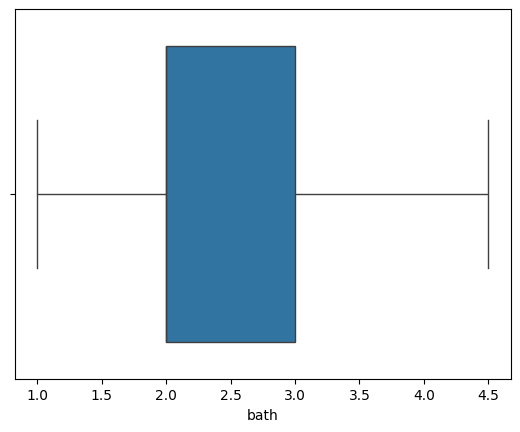

In [39]:
sns.boxplot(x=X_train['bath'])

In [40]:
df.head()

,area_type,availability,location,society,total_sqft,bath,balcony,price,size_clean,size_type
0,Super built-up Area,19-Dec,Electronic City Phase II,Coomee,1056.0,2.0,1.0,39.07,2,bedroom
1,Plot Area,Ready To Move,Chikka Tirupathi,Theanmp,2600.0,5.0,3.0,120.00,4,bedroom
2,Built-up Area,Ready To Move,Uttarahalli,Unknown,1440.0,2.0,3.0,62.00,3,bedroom
3,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,1521.0,3.0,1.0,95.00,3,bedroom
4,Super built-up Area,Ready To Move,Kothanur,Unknown,1200.0,2.0,1.0,51.00,2,bedroom


<Axes: xlabel='total_sqft'>

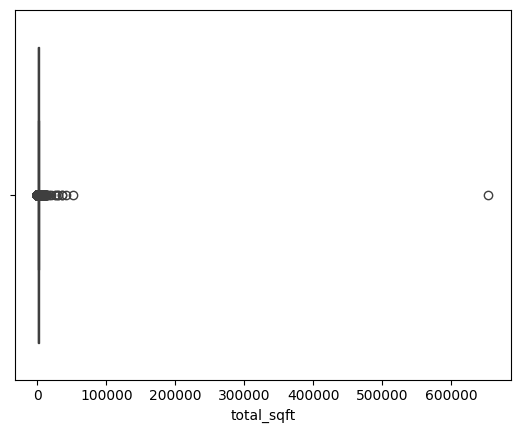

In [41]:
sns.boxplot(x=df['total_sqft'])

In [42]:
X_train.sample(10)

,area_type,availability,location,society,total_sqft,bath,balcony,size_clean,size_type
1533,Super built-up Area,Ready To Move,Kanakpura Road,Puestol,1843.0,3.0,2.0,3,bedroom
7612,Built-up Area,Ready To Move,Yelahanka,Unknown,3990.0,4.0,1.0,4,bedroom
2890,Super built-up Area,Ready To Move,7th Phase JP Nagar,Vasta C,1385.0,2.0,2.0,3,bedroom
12971,Super built-up Area,Ready To Move,Seetharampalya,Dwntsli,1360.0,2.0,2.0,3,bedroom
9900,Plot Area,Ready To Move,AMS Layout,Unknown,1200.0,4.0,1.0,4,bedroom
1895,Super built-up Area,18-Nov,Kengeri,VBn 2lm,726.0,2.0,1.0,2,bedroom
413,Plot Area,Ready To Move,Mahalakshmi Layout,Unknown,1200.0,4.5,3.0,6,bedroom
1916,Super built-up Area,Ready To Move,BTM Layout,Mames M,1150.0,2.0,2.0,2,bedroom
3661,Super built-up Area,Ready To Move,CV Raman Nagar,Villeka,1070.0,2.0,2.0,2,bedroom
10360,Built-up Area,Ready To Move,Vishveshwarya Layout,Unknown,4000.0,4.5,0.0,6,bedroom


In [43]:
X_train['location'].value_counts()

location
Whitefield                                            434
Sarjapur  Road                                        326
Electronic City                                       235
Kanakpura Road                                        217
Thanisandra                                           189
Yelahanka                                             170
Uttarahalli                                           150
Raja Rajeshwari Nagar                                 140
Marathahalli                                          140
Hebbal                                                138
Hennur Road                                           121
7th Phase JP Nagar                                    121
Haralur Road                                          118
Bannerghatta Road                                     117
Electronic City Phase II                              103
Rajaji Nagar                                           89
Chandapura                                             85
Bella

In [44]:
freq=X_train['location'].value_counts()
X_train['location']=X_train['location'].apply(lambda x:x if freq[x]>1 else 'others')

In [45]:
df['availability'].value_counts()

availability
Ready To Move           10581
18-Dec                    307
18-May                    295
18-Apr                    271
18-Aug                    200
19-Dec                    185
18-Jul                    143
18-Mar                    131
18-Jun                     99
20-Dec                     98
21-Dec                     93
19-Mar                     88
18-Feb                     62
18-Nov                     47
18-Jan                     43
18-Sep                     41
19-Jun                     40
18-Oct                     39
19-Jan                     39
19-Jul                     36
17-Dec                     29
20-Jan                     24
19-Sep                     21
17-Oct                     21
22-Jun                     19
19-Aug                     18
21-Jun                     17
Immediate Possession       16
20-Aug                     16
19-Apr                     16
19-Oct                     15
21-Mar                     14
17-Jun                     

# Scaling


In [46]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
cols=['total_sqft','bath','balcony','size_clean']
X_train[cols]=scaler.fit_transform(X_train[cols])
X_test[cols]=scaler.transform(X_test[cols])

In [47]:
X_train.head()

,area_type,availability,location,society,total_sqft,bath,balcony,size_clean,size_type
3411,Super built-up Area,Ready To Move,Lingadheeranahalli,Soiewre,-0.007269,-0.629081,0.518147,0.153913,bedroom
9142,Super built-up Area,Ready To Move,Cooke Town,Unknown,-0.174459,-0.629081,0.518147,-0.645745,bedroom
1971,Super built-up Area,Ready To Move,Raja Rajeshwari Nagar,GrrvaGr,-0.007269,0.461002,0.518147,0.153913,bedroom
2608,Plot Area,Ready To Move,Banashankari,Unknown,0.653894,0.461002,0.518147,0.953571,bedroom
9635,Built-up Area,19-Dec,Kanakapura,GoityEt,-0.397127,-0.629081,-0.738598,-0.645745,bedroom


# Ordinal Encoding


In [62]:
X_train_trf

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]], shape=(10656, 2))

In [60]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
encoder=OrdinalEncoder()
X_train['size_type']=encoder.fit_transform(X_train[['size_type']])
X_test['size_type']=encoder.transform(X_test[['size_type']])

ohe=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
X_train_trf=ohe.fit_transform(X_train[['area_type']])
X_test_trf=ohe.transform(X_test[['area_type']])

In [65]:
encoded_train = pd.DataFrame(
   X_train_trf,
    columns=ohe.get_feature_names_out(['area_type']),
    index=X_train.index
)

encoded_test = pd.DataFrame(
    X_test_trf,
    columns=ohe.get_feature_names_out(['area_type']),
    index=X_test.index
)

X_train = X_train.drop('area_type', axis=1)
X_test = X_test.drop('area_type', axis=1)

X_train = pd.concat([X_train, encoded_train], axis=1)
X_test = pd.concat([X_test, encoded_test], axis=1)

In [67]:
X_train.head()

,availability,location,society,total_sqft,bath,balcony,size_clean,size_type,area_type_0.0,area_type_1.0
3411,Ready To Move,Lingadheeranahalli,Soiewre,-0.007269,-0.629081,0.518147,0.153913,0.0,1.0,0.0
9142,Ready To Move,Cooke Town,Unknown,-0.174459,-0.629081,0.518147,-0.645745,0.0,1.0,0.0
1971,Ready To Move,Raja Rajeshwari Nagar,GrrvaGr,-0.007269,0.461002,0.518147,0.153913,0.0,1.0,0.0
2608,Ready To Move,Banashankari,Unknown,0.653894,0.461002,0.518147,0.953571,0.0,1.0,0.0
9635,19-Dec,Kanakapura,GoityEt,-0.397127,-0.629081,-0.738598,-0.645745,0.0,0.0,1.0


In [49]:
X_train['area_type'].value_counts()

area_type
Super built-up  Area    7021
Built-up  Area          1952
Plot  Area              1615
Carpet  Area              68
Name: count, dtype: int64

In [ ]:
from sklearn.preprocessing import OneHotEncoder